In [5]:
import os
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt

# Paths to your data
DATA_DIR = '../data'  # Assuming your normal/abnormal folders are inside here
NORMAL_DIR = os.path.join(DATA_DIR, 'normal')
ABNORMAL_DIR = os.path.join(DATA_DIR, 'abnormal')

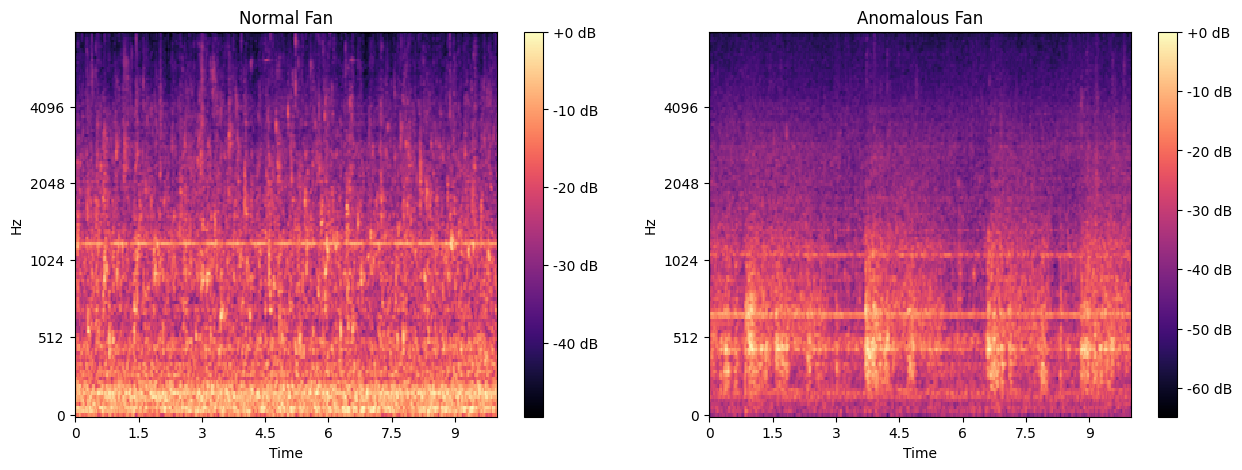

In [6]:
def plot_comparison(norm_path, abnorm_path):
    plt.figure(figsize=(15, 5))
    
    for i, path in enumerate([norm_path, abnorm_path]):
        # Load audio (16kHz is usually best for industrial)
        y, sr = librosa.load(path, sr=16000)
        
        # Convert to Mel-spectrogram
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
        S_dB = librosa.power_to_db(S, ref=np.max)
        
        plt.subplot(1, 2, i+1)
        librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel')
        plt.title("Normal Fan" if i==0 else "Anomalous Fan")
        plt.colorbar(format='%+2.0f dB')
        
    plt.show()

# Test it with your files (Update names if needed!)
plot_comparison(os.path.join(NORMAL_DIR, os.listdir(NORMAL_DIR)[0]), 
                os.path.join(ABNORMAL_DIR, os.listdir(ABNORMAL_DIR)[0]))

In [7]:
def process_folder(folder_path, label):
    data = []
    labels = []
    for filename in os.listdir(folder_path):
        if filename.endswith('.wav'):
            file_path = os.path.join(folder_path, filename)
            y, sr = librosa.load(file_path, sr=16000)
            
            # Extract Mel Spectrogram
            S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
            S_dB = librosa.power_to_db(S, ref=np.max)
            
            # Normalize to 0-1 range (Crucial for AI training!)
            S_dB = (S_dB - np.min(S_dB)) / (np.max(S_dB) - np.min(S_dB))
            
            data.append(S_dB)
            labels.append(label)
    return np.array(data), np.array(labels)

# Process everything
X_norm, y_norm = process_folder(NORMAL_DIR, 0)
X_abnorm, y_abnorm = process_folder(ABNORMAL_DIR, 1)

# Combine and save for Notebook 02
X = np.concatenate([X_norm, X_abnorm], axis=0)
y = np.concatenate([y_norm, y_abnorm], axis=0)

np.save('X_features.npy', X)
np.save('y_labels.npy', y)
print(f"🚀 Success! Saved {len(X)} samples to 'X_features.npy'")

🚀 Success! Saved 519 samples to 'X_features.npy'
